---------------------
FileFormat: 123
SystemType: 1
RecordingProgramName: b'IQUA'
RecordingProgramVersion: b'100'
SonarName: b'ScoutMkII_ros'
SonarType: 44
NoteString: b'Marine Sonic Technology Corp.'
ThisFileName: b'/home/user/logs/mk_ii/2025-09-24_09-25-24_0.xtf'
NavUnits: 3
NumberOfSonarChannels: 2
NumberOfBathymetryChannels: 0
NumberOfSnippetChannels: 0
NumberOfForwardLookArrays: 0
NumberOfEchoStrengthChannels: 0
NumberOfInterferometryChannels: 0
Reserved1: 0
Reserved2: 0
ReferencePointHeight: 0.0
ProjectionType: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
SpheriodType: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
NavigationLatency: 0
OriginY: 0.0
OriginX: 0.0
NavOffsetY: 0.0
NavOffsetX: 0.0
NavOffsetZ: 0.0
NavOffsetYaw: 0.0
MRUOffsetY: 0.0
MRUOffsetX: 0.0
MRUOffsetZ: 0.0
MRUOffsetYaw: 0.0
MRUOffsetPitch: 0.0
MRUOffsetRoll: 0.0
ChanInfo: [<pyxtf.xtf_ctypes.XTFChanInfo object at 0x7e4ea79051d0>, <pyxtf.xtf_ctypes.XTFChanInfo object at 0x7e4ea7905250>, <pyxtf.xtf_ctypes.XTFChanInfo object at 0x7e4ea79052

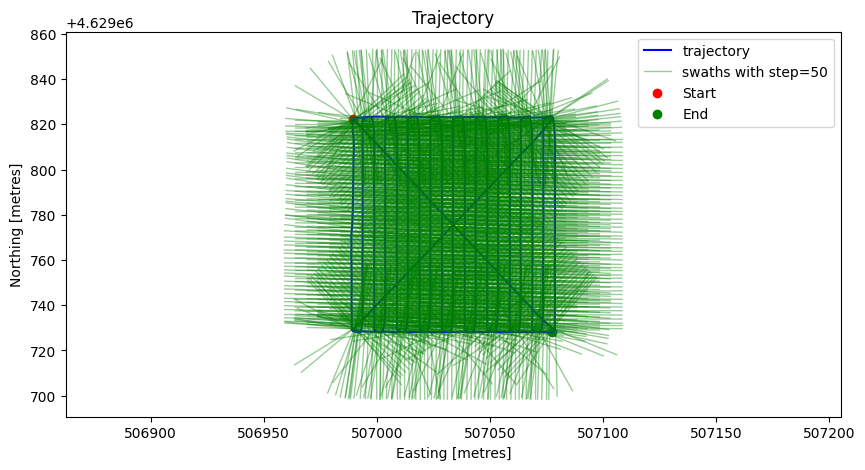

In [1]:
import physdnet.xtf_utils as xtf_utils
import matplotlib.pyplot as plt 

data_load = xtf_utils.load_xtf("/home/juan/Documents/IFROS/perception/HoP/HoP-SSS-Loop-Closure/data/2025-09-24_09-25-24_0.xtf")

swaths, trajectory, altitude, roll, pitch, yaw = xtf_utils.calculate_swath_positions(data_load)


_, ax = plt.subplots(figsize=(10,5))

# Plot trajectory
ax.plot(trajectory[:,0], trajectory[:,1], color="blue", label="trajectory")

# Plot ping lines 
step = 50
for i in range(0, swaths.shape[0], step):
    start_point = swaths[i, 0, :]      
    end_point = swaths[i, -1, :]       
    
    x_vals = [start_point[0], end_point[0]]
    y_vals = [start_point[1], end_point[1]]
    
    if i == 0:
        ax.plot(x_vals, y_vals, color='green', linestyle='-', alpha=0.4, linewidth=1, label=f"swaths with step={step}")
    else:    
        ax.plot(x_vals, y_vals, color='green', linestyle='-', alpha=0.4, linewidth=1)

ax.axis("equal")
ax.set_title("Trajectory")
ax.set_xlabel("Easting [metres]")
ax.set_ylabel("Northing [metres]")
ax.axis("equal")
ax.scatter([trajectory[0,0]], [trajectory[0,1]], label="Start", c="red")
ax.scatter([trajectory[-1,0]], [trajectory[-1,1]], label="End", c="green")
ax.legend()

plt.show()


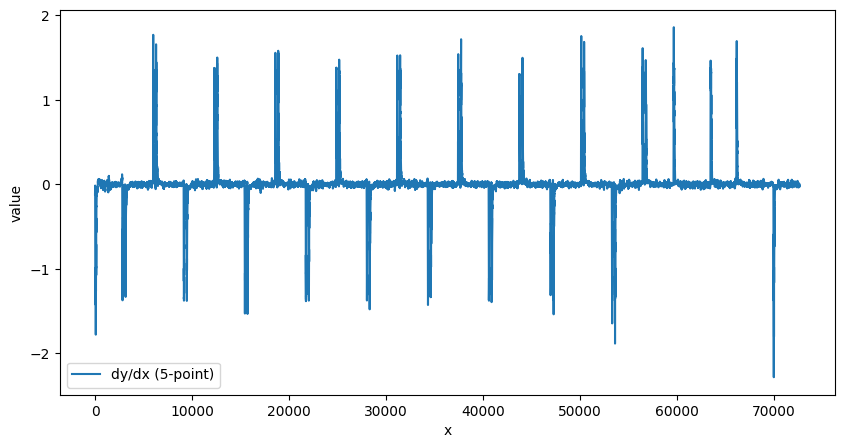

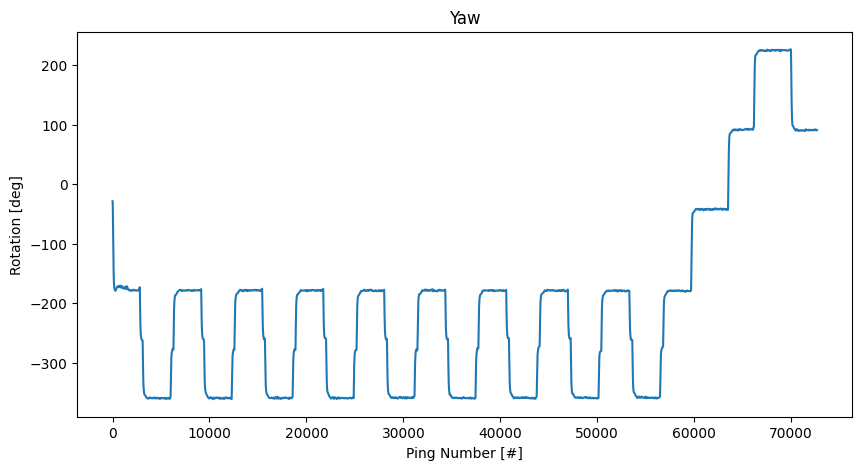

In [2]:
import numpy as np
import matplotlib.pyplot as plt

def numerical_derivative_5point(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    if len(x) != len(y):
        raise ValueError("x and y must have the same length")
    if len(x) < 5:
        raise ValueError("Need at least 5 points")

    h = x[1] - x[0]
    if not np.allclose(np.diff(x), h):
        raise ValueError("This 5-point formula assumes equally spaced x values")

    dydx = np.empty_like(y)

    # Forward 5-point formula for first two points
    dydx[0] = (-25*y[0] + 48*y[1] - 36*y[2] + 16*y[3] - 3*y[4]) / (12*h)
    dydx[1] = (-3*y[0] - 10*y[1] + 18*y[2] - 6*y[3] + y[4]) / (12*h)

    # Central 5-point formula for interior points
    for i in range(2, len(y) - 2):
        dydx[i] = (y[i-2] - 8*y[i-1] + 8*y[i+1] - y[i+2]) / (12*h)

    # Backward 5-point formula for last two points
    dydx[-2] = (-y[-5] + 6*y[-4] - 18*y[-3] + 10*y[-2] + 3*y[-1]) / (12*h)
    dydx[-1] = (3*y[-5] - 16*y[-4] + 36*y[-3] - 48*y[-2] + 25*y[-1]) / (12*h)

    return dydx

dy = numerical_derivative_5point(np.arange(len(np.unwrap(yaw)*180/np.pi)), np.unwrap(yaw)*180/np.pi)

_, ax = plt.subplots(figsize=(10,5))
ax.plot(np.arange(len(np.unwrap(yaw)*180/np.pi)), dy, label="dy/dx (5-point)")
ax.set_xlabel("x")
ax.set_ylabel("value")
ax.legend()
plt.show()

_, ax = plt.subplots(figsize=(10,5))
ax.plot(np.unwrap(yaw)*180/np.pi)
ax.set_title("Yaw")
ax.set_xlabel("Ping Number [#]")
ax.set_ylabel("Rotation [deg]")
plt.show()


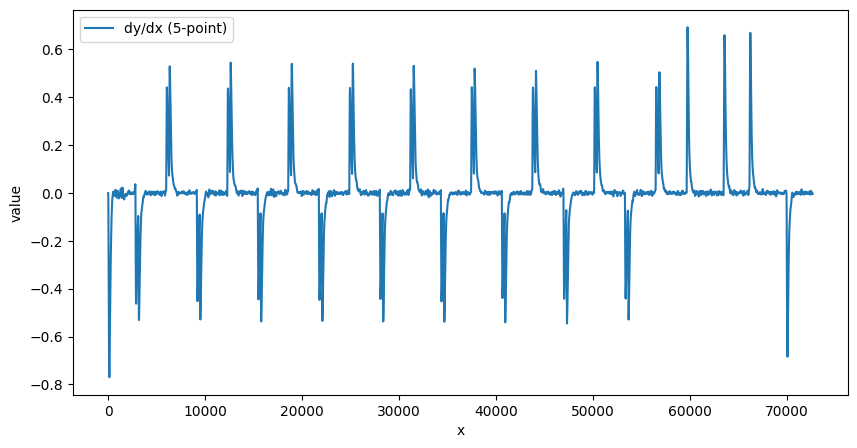

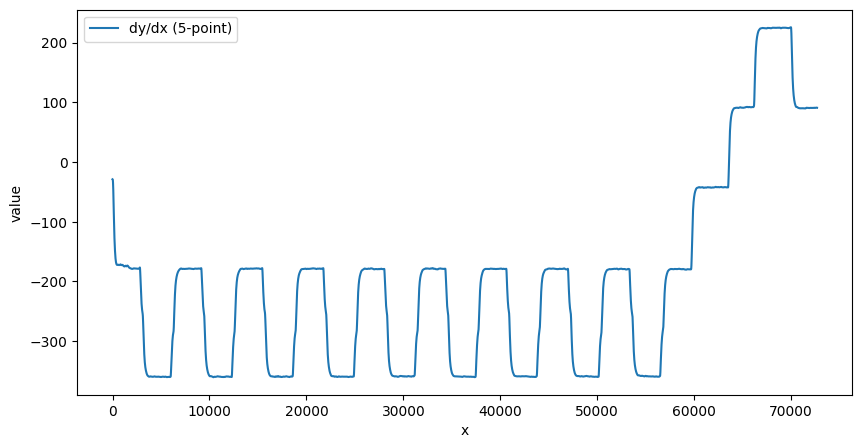

In [3]:
def lowpass_and_derivative_5point(x, y, alpha=0.2):
    """
    Applies a simple low-pass filter first, then computes the numerical
    derivative using a 5-point finite-difference stencil.

    Parameters
    ----------
    x : array-like
        Equally spaced x values.
    y : array-like
        Signal values.
    alpha : float
        Low-pass filter coefficient in (0, 1].
        Smaller -> stronger smoothing.

    Returns
    -------
    y_filt : np.ndarray
        Low-pass filtered signal.
    dydx : np.ndarray
        Numerical derivative of filtered signal.
    """
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    if len(x) != len(y):
        raise ValueError("x and y must have the same length")
    if len(x) < 5:
        raise ValueError("Need at least 5 points")

    h = x[1] - x[0]
    if not np.allclose(np.diff(x), h):
        raise ValueError("This 5-point formula assumes equally spaced x values")

    if not (0 < alpha <= 1):
        raise ValueError("alpha must be in the range (0, 1]")

    # Low-pass filter: exponential smoothing
    y_filt = np.empty_like(y)
    y_filt[0] = y[0]
    for i in range(1, len(y)):
        y_filt[i] = alpha * y[i] + (1 - alpha) * y_filt[i - 1]

    # 5-point derivative
    dydx = np.empty_like(y_filt)

    # Forward formulas
    dydx[0] = (-25*y_filt[0] + 48*y_filt[1] - 36*y_filt[2] + 16*y_filt[3] - 3*y_filt[4]) / (12*h)
    dydx[1] = (-3*y_filt[0] - 10*y_filt[1] + 18*y_filt[2] - 6*y_filt[3] + y_filt[4]) / (12*h)

    # Central formula
    for i in range(2, len(y_filt) - 2):
        dydx[i] = (y_filt[i - 2] - 8*y_filt[i - 1] + 8*y_filt[i + 1] - y_filt[i + 2]) / (12*h)

    # Backward formulas
    dydx[-2] = (-y_filt[-5] + 6*y_filt[-4] - 18*y_filt[-3] + 10*y_filt[-2] + 3*y_filt[-1]) / (12*h)
    dydx[-1] = (3*y_filt[-5] - 16*y_filt[-4] + 36*y_filt[-3] - 48*y_filt[-2] + 25*y_filt[-1]) / (12*h)

    return y_filt, dydx

filter, dy = lowpass_and_derivative_5point(np.arange(len(np.unwrap(yaw)*180/np.pi)), np.unwrap(yaw)*180/np.pi, 0.01)

_, ax = plt.subplots(figsize=(10,5))
ax.plot(np.arange(len(np.unwrap(yaw)*180/np.pi)), dy, label="dy/dx (5-point)")
ax.set_xlabel("x")
ax.set_ylabel("value")
ax.legend()
plt.show()

_, ax = plt.subplots(figsize=(10,5))
ax.plot(np.arange(len(np.unwrap(yaw)*180/np.pi)), filter, label="dy/dx (5-point)")
ax.set_xlabel("x")
ax.set_ylabel("value")
ax.legend()
plt.show()

In [4]:
Ids = np.where(np.abs(dy)>0.08)[0]
print("Indices where dy/dx > 0.5:", Ids)

Indices where dy/dx > 0.5: [   29    30    31 ... 70356 70357 70358]


In [5]:

new_index = range(0, swaths.shape[0],1)
new_index = np.delete(new_index,Ids)

print("Ids of interest: ", new_index)

Ids of interest:  [    0     1     2 ... 72672 72673 72674]


In [17]:
changes = 1
jumps = np.where(np.diff(new_index) > changes)[0] + 1


groups = np.split(new_index, jumps)

groups_indexes = [g for g in groups if len(g) > 26]

print("Count of groups: ", len(groups))

print("Count of groups_indexes: ", len(groups_indexes))
max_values = [np.max(i) for i in groups_indexes]

Count of groups:  30
Count of groups_indexes:  24


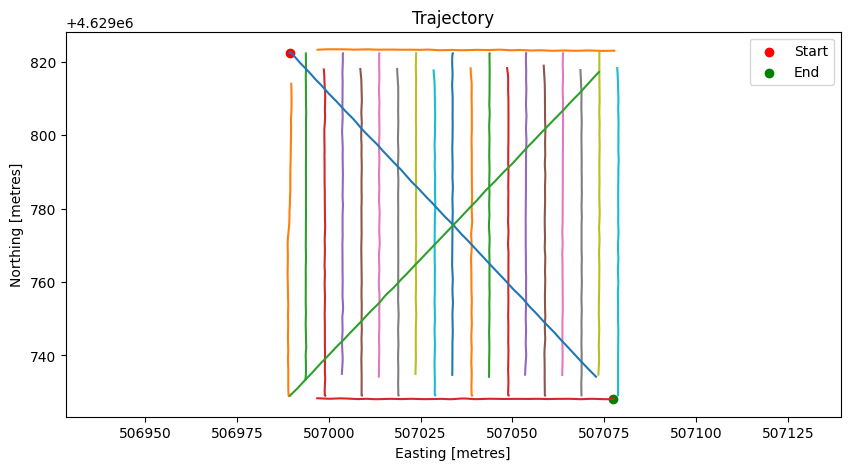

In [19]:
_, ax = plt.subplots(figsize=(10,5))

for i in range(len(groups_indexes)):
    minimum = min(groups_indexes[i])
    maximum = max(groups_indexes[i])
    # Plot trajectory
    ax.plot(trajectory[minimum:maximum,0], trajectory[minimum:maximum,1])

ax.axis("equal")
ax.set_title("Trajectory")
ax.set_xlabel("Easting [metres]")
ax.set_ylabel("Northing [metres]")
ax.axis("equal")
ax.scatter([trajectory[0,0]], [trajectory[0,1]], label="Start", c="red")
ax.scatter([trajectory[-1,0]], [trajectory[-1,1]], label="End", c="green")
ax.legend()

plt.show()